In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
f = "../data/ClimaLab_2023-05-31_2025-06-20.parquet"
esolmet = pd.read_parquet(f)
esolmet.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1076768 entries, 2023-05-31 18:59:00 to 2025-06-20 00:00:00
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   dhi             543232 non-null   float64
 1   dni             541781 non-null   float64
 2   ghi             543189 non-null   float64
 3   p_atm           1076768 non-null  float64
 4   rain_acc        1076768 non-null  float64
 5   rh              1076768 non-null  float64
 6   solar_altitude  1076768 non-null  float64
 7   tdb             1076768 non-null  float64
 8   uv              1076768 non-null  float64
 9   wd              1076768 non-null  float64
 10  ws              1076768 non-null  float64
dtypes: float64(11)
memory usage: 98.6 MB


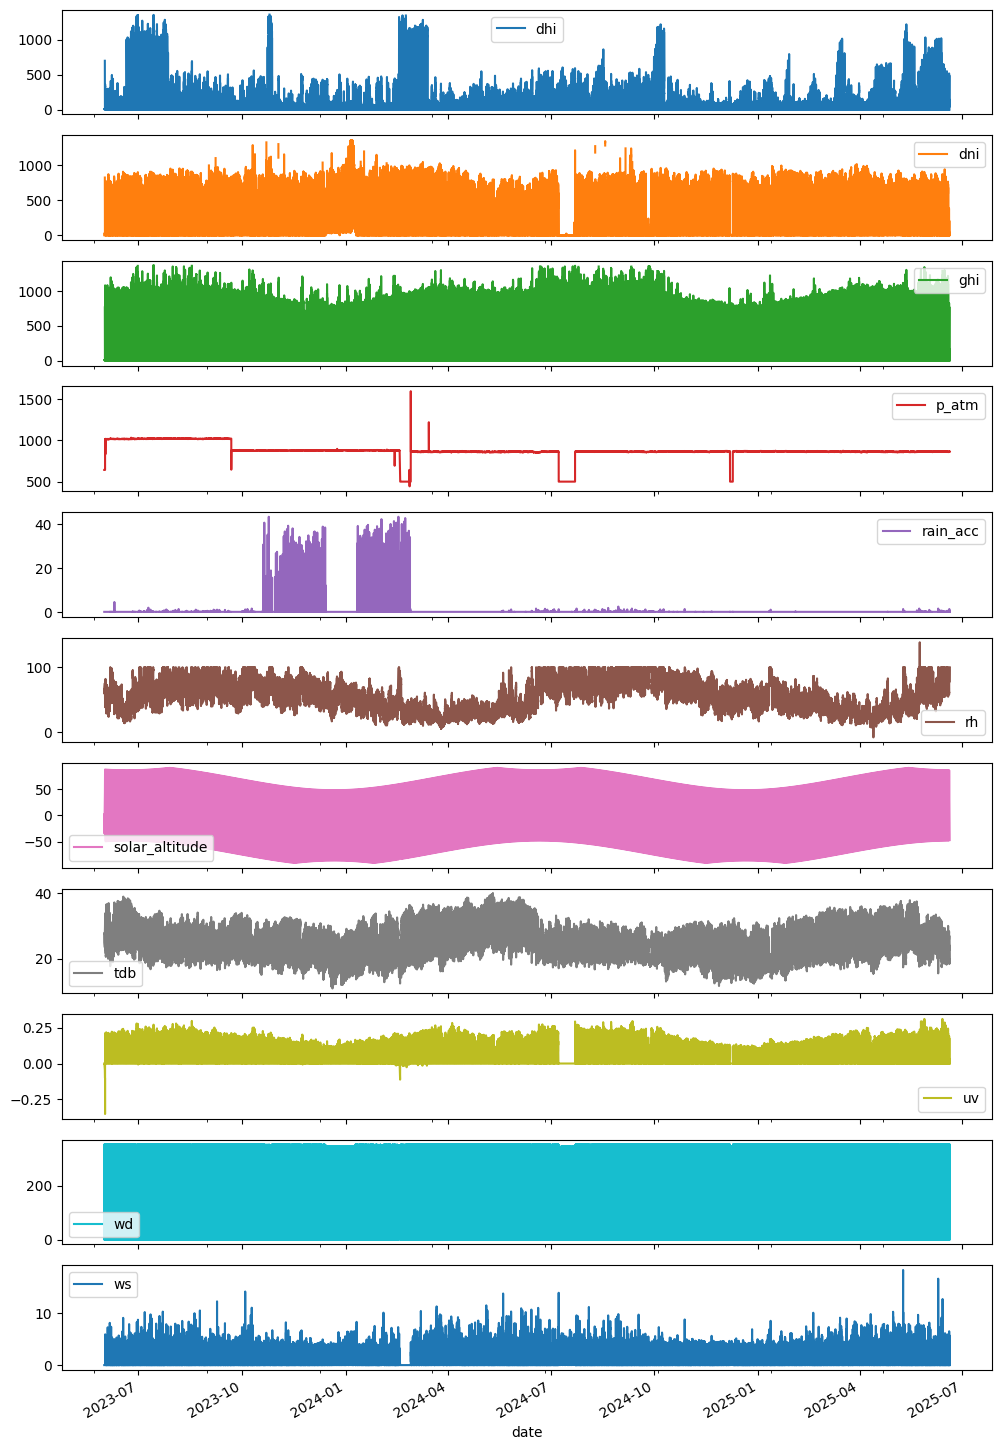

In [3]:
esolmet.plot(subplots=True,figsize=(12,20));

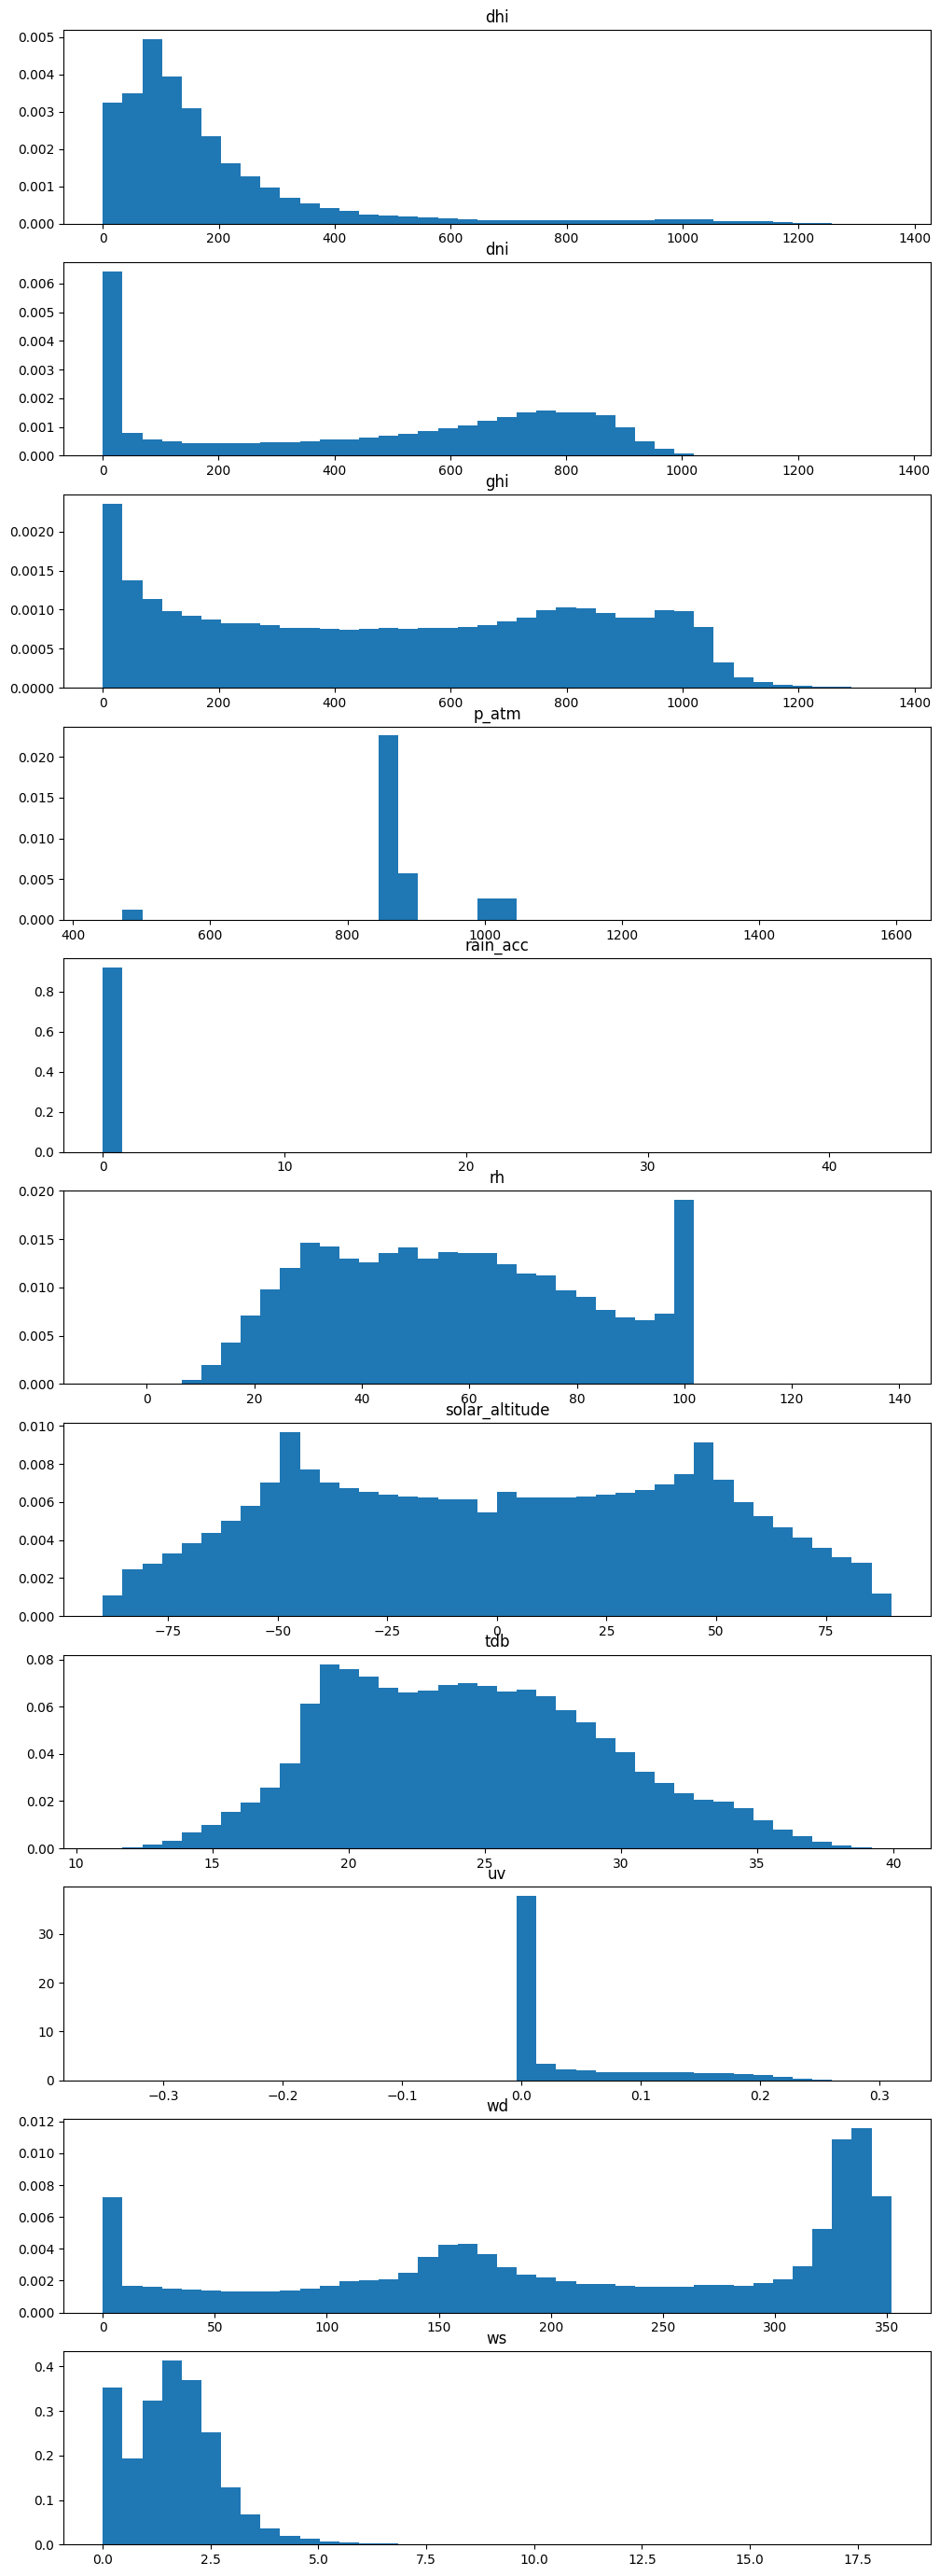

In [4]:
columnas = esolmet.columns

fig, ax = plt.subplots(len(columnas), 1,figsize=(12,35))
for i,columna in enumerate(columnas):
    ax[i].hist(esolmet[columna],bins=40,density=True)
    ax[i].set_title(columna)

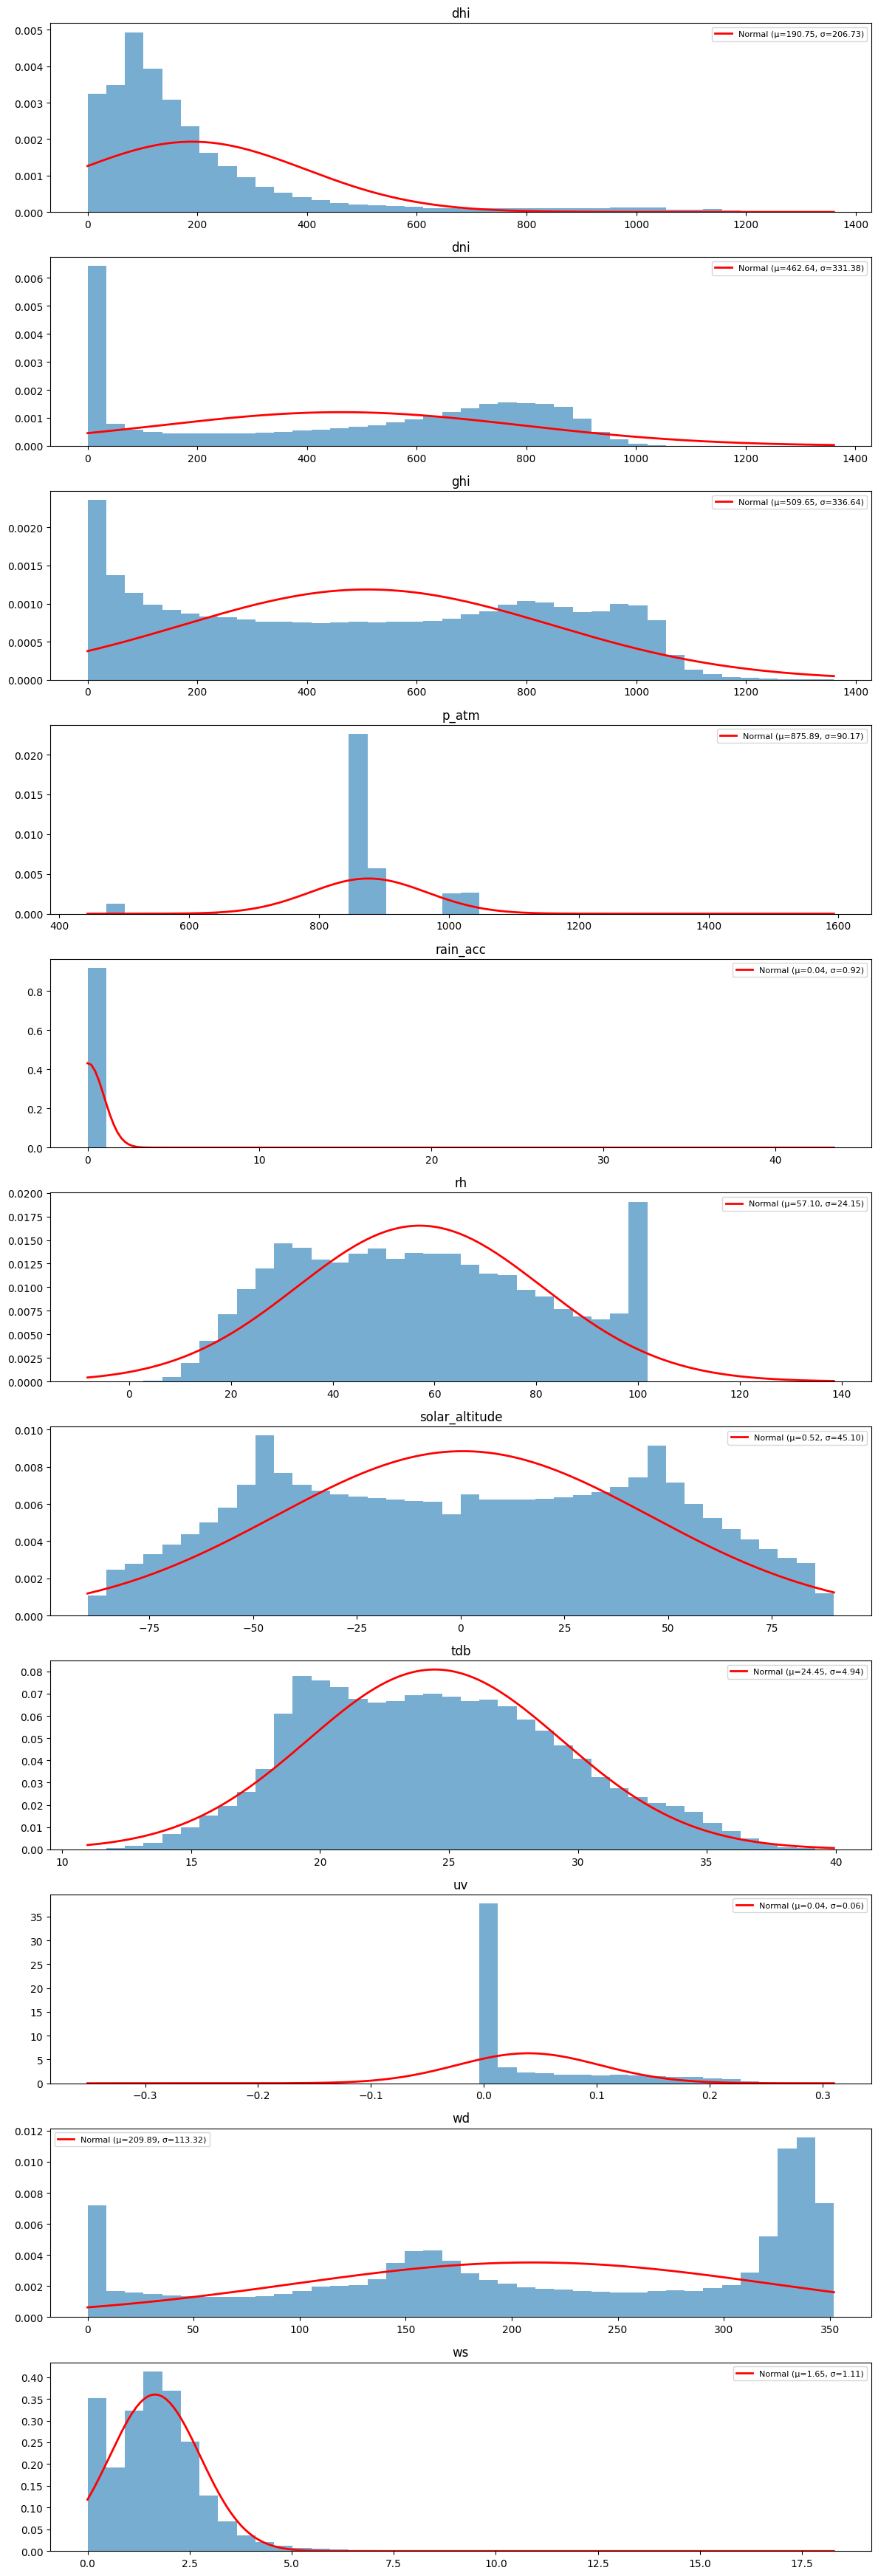

In [5]:

columnas = esolmet.columns
fig, ax = plt.subplots(len(columnas), 1, figsize=(12, 35))

for i, columna in enumerate(columnas):
    data = esolmet[columna].dropna()
    
    ax[i].hist(data, bins=40, density=True, alpha=0.6)
    
    mu = data.mean()
    sigma = data.std()
    
    x = np.linspace(data.min(), data.max(), 200)
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    
    ax[i].plot(x, pdf, 'r-', lw=2, label=f'Normal (μ={mu:.2f}, σ={sigma:.2f})')
    ax[i].set_title(columna)
    ax[i].legend(fontsize=8)

plt.tight_layout()

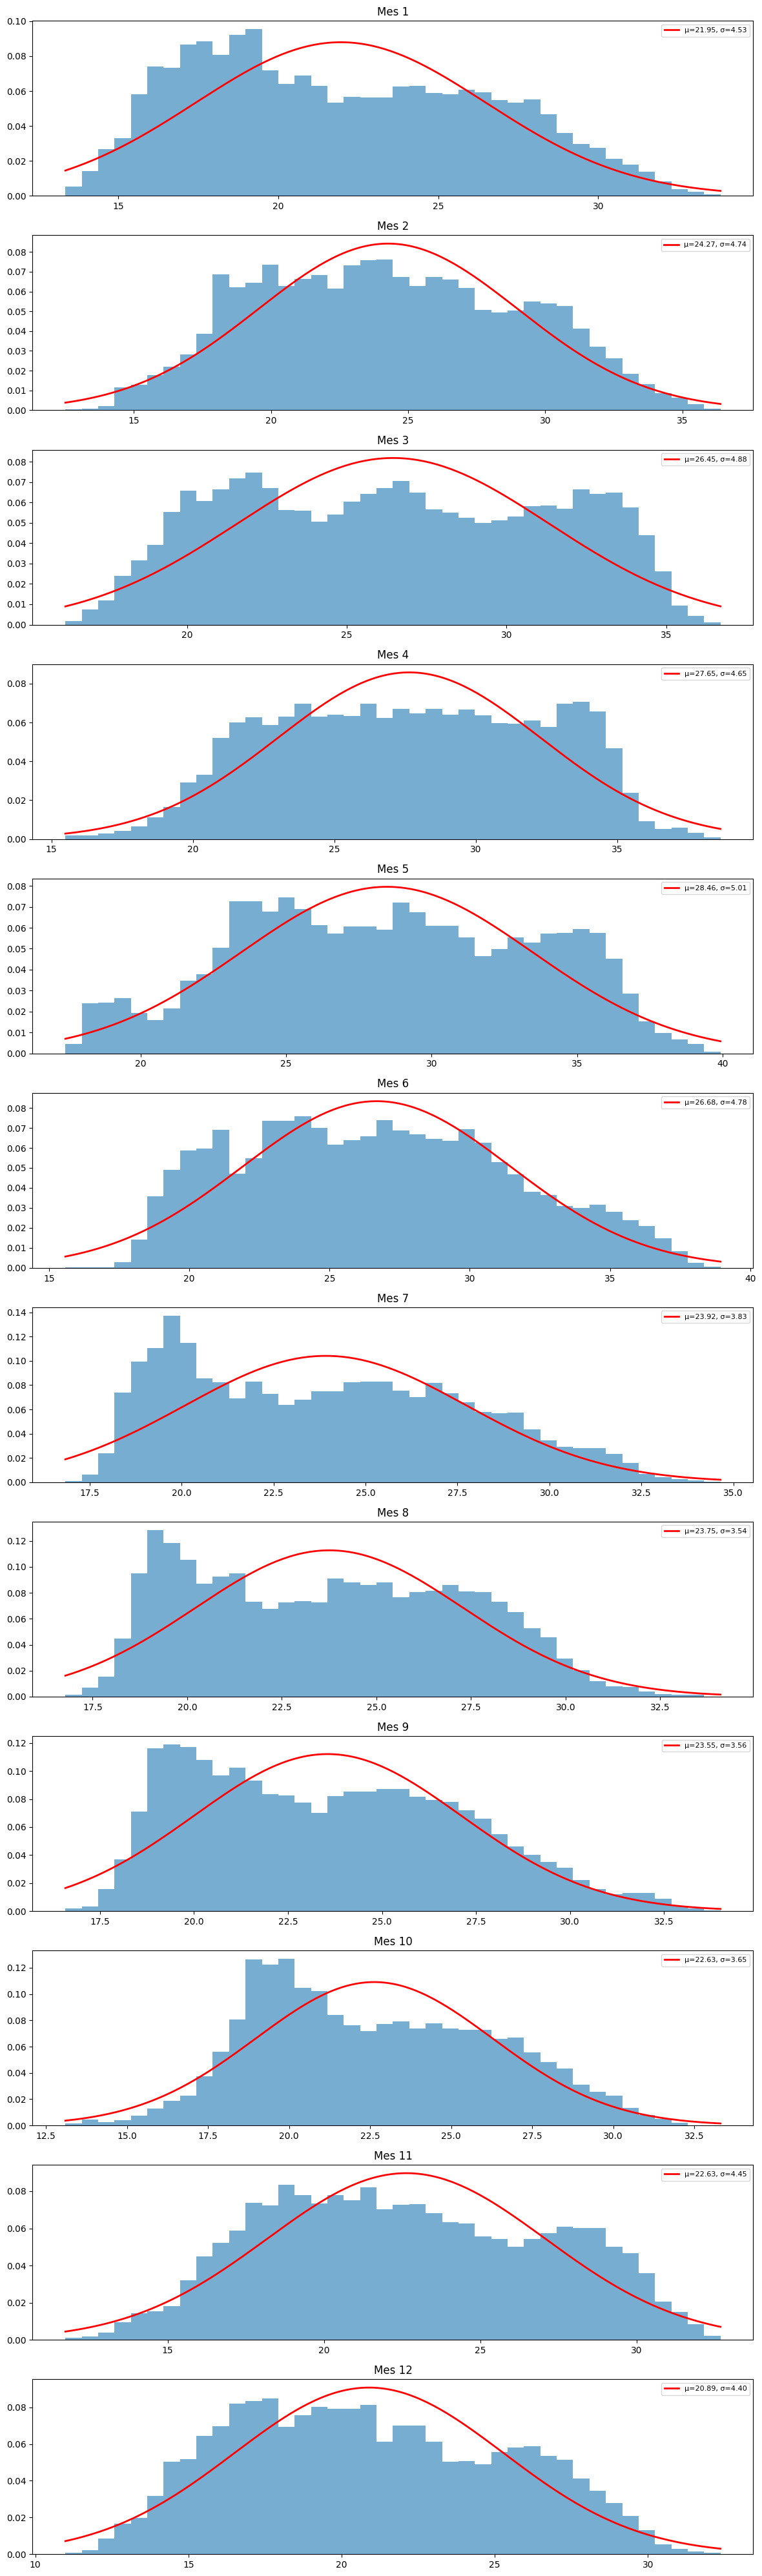

In [6]:
fig, ax = plt.subplots(12, 1, figsize=(12, 40))

for i, mes in enumerate(range(1, 13)):
    
    # Máscara por mes usando el índice datetime
    mascara = esolmet.index.month == mes
    data = esolmet.loc[mascara, 'tdb'].dropna()
    
    mu = data.mean()
    sigma = data.std()
    
    x = np.linspace(data.min(), data.max(), 200)
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    
    ax[i].hist(data, bins=40, density=True, alpha=0.6)
    ax[i].plot(x, pdf, 'r-', lw=2, label=f'μ={mu:.2f}, σ={sigma:.2f}')
    ax[i].set_title(f'Mes {mes}')
    ax[i].legend(fontsize=8)

plt.tight_layout()

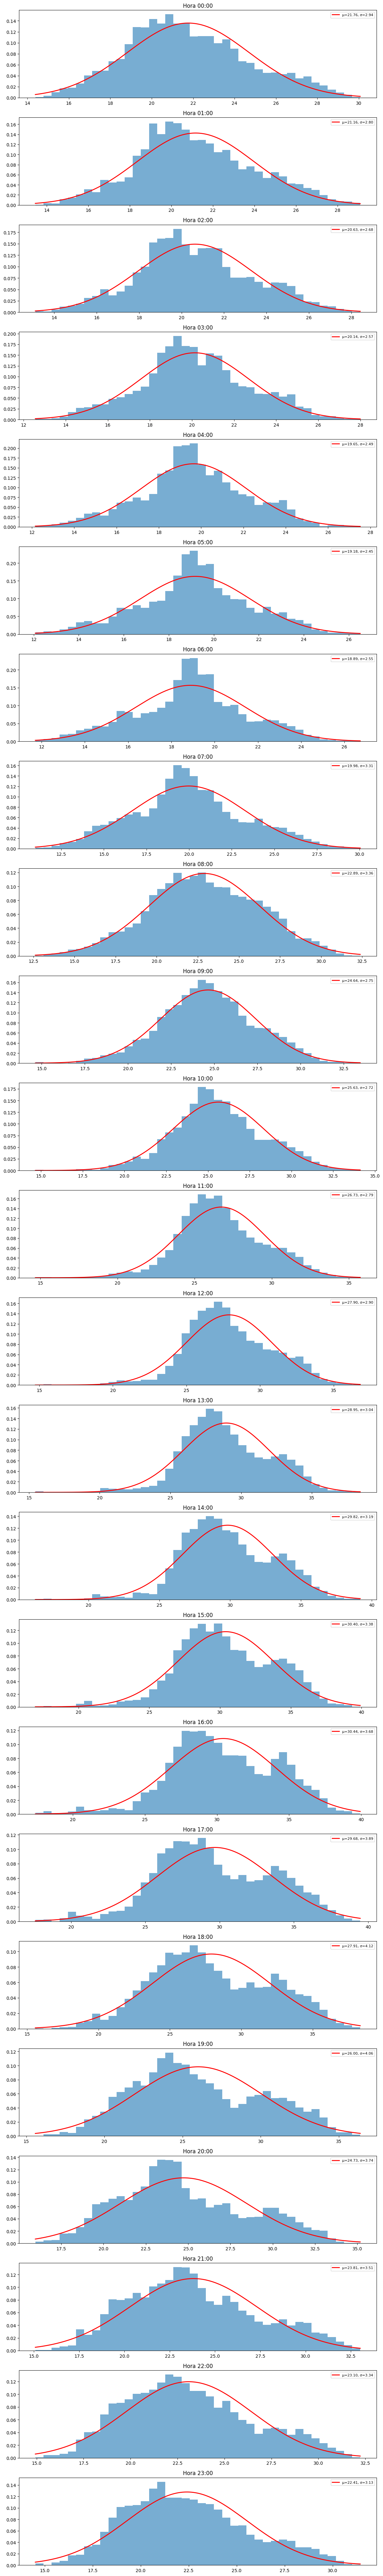

In [7]:
fig, ax = plt.subplots(24, 1, figsize=(12, 80))

for i, hora in enumerate(range(0, 24)):
    
    mascara = esolmet.index.hour == hora
    data = esolmet.loc[mascara, 'tdb'].dropna()
    
    mu = data.mean()
    sigma = data.std()
    
    x = np.linspace(data.min(), data.max(), 200)
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    
    ax[i].hist(data, bins=40, density=True, alpha=0.6)
    ax[i].plot(x, pdf, 'r-', lw=2, label=f'μ={mu:.2f}, σ={sigma:.2f}')
    ax[i].set_title(f'Hora {hora:02d}:00')
    ax[i].legend(fontsize=8)

plt.tight_layout()

In [10]:
  
mascara = esolmet.index.hour == 9
nueve = pd.DataFrame(esolmet.loc[mascara, 'tdb'].dropna())
nueve

,tdb
date,
2023-06-01 09:00:00,26.98
2023-06-01 09:01:00,26.93
2023-06-01 09:02:00,26.82
2023-06-01 09:03:00,26.75
2023-06-01 09:04:00,26.87
...,...
2025-06-19 09:55:00,26.83
2025-06-19 09:56:00,26.77
2025-06-19 09:57:00,26.66


In [11]:
nueve.to_parquet("../data/tbd_9horas.parquet")